# SAM Instance Debugger

Build the cache first with `build_rgb_cache.py`, then use this notebook to step the standalone SAM-instance algorithm frame by frame.

The notebook intentionally keeps the control surface small:
- adjust the hyperparameters in one cell
- recreate the debugger after edits
- use the widget to step / seek / jump to the next seed frame
- inspect detailed decisions and bucket state in the text panel

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '5'

In [2]:
from pathlib import Path

from map_runtime.sam_instance_debug import CachedSAMInstanceDebugger, DebuggerConfig, create_debugger_widget
from map_runtime.sam_masks import SAMAutomaticMaskConfig

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [3]:
# F3RM reference, from /robodata/smodak/repos/f3rm/f3rm/features/sam_extract.py
# plus underlying segment_anything.SamAutomaticMaskGenerator defaults for fields F3RM leaves as None.
# sam_amg_config_f3rm = SAMAutomaticMaskConfig(
#     sort_mode="area",
#     min_mask_area_perc=0.01,
#     points_per_side=8,
#     points_per_batch=64,
#     pred_iou_thresh=0.88,
#     stability_score_thresh=0.95,
#     stability_score_offset=1.0,
#     mask_threshold=0.0,
#     box_nms_thresh=0.7,
#     crop_n_layers=0,
#     crop_nms_thresh=0.7,
#     crop_overlap_ratio=0.3413333333333333,
#     crop_n_points_downscale_factor=1,
#     point_grids=None,
#     min_mask_region_area=0,
#     output_mode="binary_mask",
#     use_m2m=False,
#     multimask_output=True,
#     score_pred_iou_power=1.0,
#     score_stability_power=1.0,
#     score_area_power=1.0,
#     mask_overlap_rescore_thresh=0.0,
#     mask_overlap_rescore_power=1.0,
#     mask_dedupe_iou_thresh=0.0,
#     mask_containment_thresh=0.0,
# )

In [4]:
CACHE_DIR = Path("data/output/rgb_caches/ScanNet/scene0011_00")

sam_amg_config = SAMAutomaticMaskConfig(
    sort_mode="score",
    min_mask_area_perc=0.01,
    points_per_side=24,
    points_per_batch=128,
    pred_iou_thresh=0.88,
    stability_score_thresh=0.92,
    stability_score_offset=1.0,
    mask_threshold=0.0,
    box_nms_thresh=0.7,
    crop_n_layers=0,
    crop_nms_thresh=0.7,
    crop_overlap_ratio=0.6,
    crop_n_points_downscale_factor=1,
    point_grids=None,
    min_mask_region_area=0,
    output_mode="binary_mask",
    use_m2m=False,
    multimask_output=True,
    score_pred_iou_power=2.0,
    score_stability_power=1.0,
    score_area_power=0.0,
    mask_overlap_rescore_thresh=0.0,
    mask_overlap_rescore_power=1.0,
    mask_dedupe_iou_thresh=0.85,
    mask_containment_thresh=0.0,
)

config = DebuggerConfig(
    point_gid_slots=10,
    sam_model_level=24,
    sam_track_model_level=24,
    sam2_max_num_objects=16,
    sam_amg_config=sam_amg_config,
    reuse_inside_frac_th=0.40,
    reuse_outside_frac_th=0.10,
    min_mask_points=1,
    min_track_visible_points=1,
    prune_every_frames=50,
    prune_stale_gap_frames=2000,
    prune_min_support_ratio=0.0005,
    prune_min_points=5000,
)

DEVICE = "cuda"

In [5]:
debugger = CachedSAMInstanceDebugger(CACHE_DIR, config, device=DEVICE)
create_debugger_widget(debugger)

In [ ]:
debugger.simulate_sam_onlyseed_video(upto=-1, map_every=1)

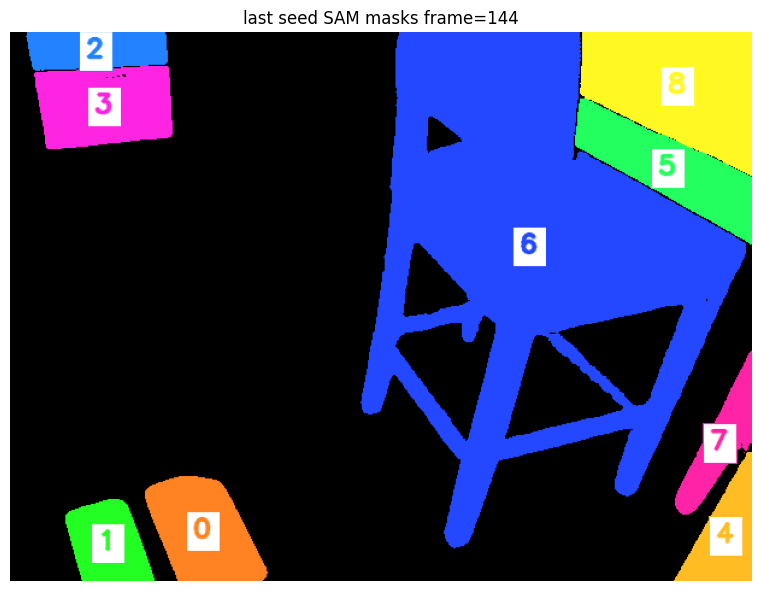

In [5]:
debugger.show_sam_masks()

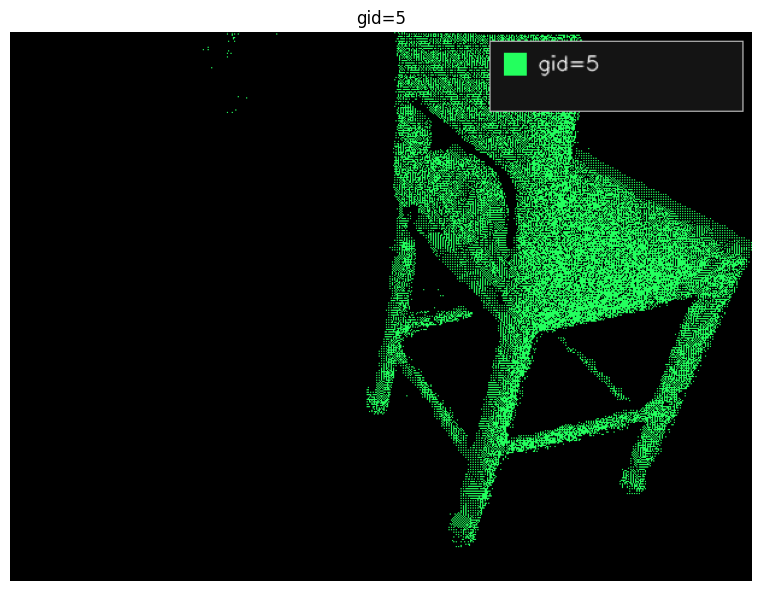

In [7]:
debugger.show(gid=5)

In [ ]:
# Bucket / point-membership queries on the current debugger state.
# Run debugger.step(), debugger.seek(...), or use the widget first so debugger.current_view is populated.
#
# gid = 3
# bucket = debugger.buckets[gid]
# bucket
#
# point_id = 12345
# debugger.point_gids[point_id]  # K=10 gid slots for one global 3D point
#
# row, col = 200, 300
# point_id = int(debugger.current_view["point_ids_after"][row, col])
# if point_id >= 0:
#     print("pixel -> point_id", point_id)
#     print("gid slots", debugger.point_gids[point_id])
#
# active_buckets = {gid: debugger.buckets[gid] for gid in debugger.current_view["seeded_gids"]}
# active_buckets


In [5]:
# Manual inspection examples
# debugger.step()
# debugger.seek(80)
# print(debugger.current_text_summary())
# debugger.current_view["decisions"]
# debugger.show(local_id=3)  # seed frames only
# debugger.show(gid=3)       # current projected global-instance support for gid=3
# debugger.show(local_id=3, gid=3)  # compare seed local mask vs current projected gid support

In [6]:
debugger.simulate_video(upto=1400)

simulate_video:   0%|          | 0/1401 [00:00<?, ?frame/s]

PosixPath('data/output/rgb_caches/ScanNet/scene0011_00/debug_videos/panel_001400.mp4')